In [1]:
import torch.nn as nn

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from utility.model import ModelConfig, EarlyStopping

In [2]:
# Parameters

r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

In [3]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

# loss_weights = {
#     'variational': 5,
#     'terminal': 5,
#     'Smax': 3,
#     'Smin': 3
# }

In [ ]:
# seeds = [40, 41, 42, 43, 44]
seeds = range(1)
for seed in seeds:
    print("Training with seed:", seed)
    pinn = BlackScholesPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigma, T, S_min, S_max)
    # pinn.set_loss_weights(loss_weights)

    early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
    pinn.train(batch_size=4096, epochs=20000, early_stopping=early_stopping, alpha=0.1)
    pinn.save(f'../models/bs_pinn_1d/annealed/{seed}.pth')

Training with seed: 0
Iter      0 | Train: 2.4364e+00 | Val: 9.9483e-01 | Weights: variational=4.853  terminal=6.328  Smin=1.520  Smax=9.513
Iter    100 | Train: 1.8723e-01 | Val: 6.2566e-01 | Weights: variational=0.747  terminal=0.401  Smin=0.232  Smax=0.306
Iter    200 | Train: 3.9521e-01 | Val: 3.5680e-01 | Weights: variational=3.032  terminal=1.299  Smin=0.845  Smax=1.168
Iter    300 | Train: 2.8826e-02 | Val: 4.4778e-02 | Weights: variational=5.986  terminal=0.556  Smin=0.926  Smax=1.403
Iter    400 | Train: 1.5525e-02 | Val: 3.0383e-02 | Weights: variational=4.200  terminal=0.441  Smin=0.831  Smax=1.003
Iter    500 | Train: 1.0020e-02 | Val: 2.2060e-02 | Weights: variational=3.463  terminal=0.385  Smin=0.784  Smax=0.833
Iter    600 | Train: 7.5389e-03 | Val: 1.6520e-02 | Weights: variational=3.347  terminal=0.383  Smin=0.821  Smax=0.792
Iter    700 | Train: 5.4044e-03 | Val: 1.2314e-02 | Weights: variational=3.244  terminal=0.355  Smin=0.806  Smax=0.699
Iter    800 | Train: 3.650

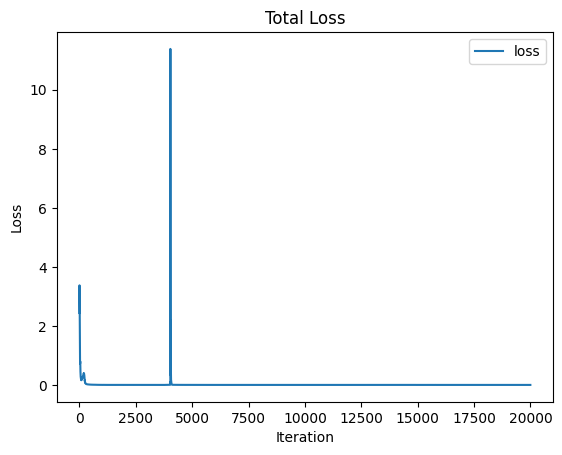

In [5]:
pinn.plot_losses()